0.0

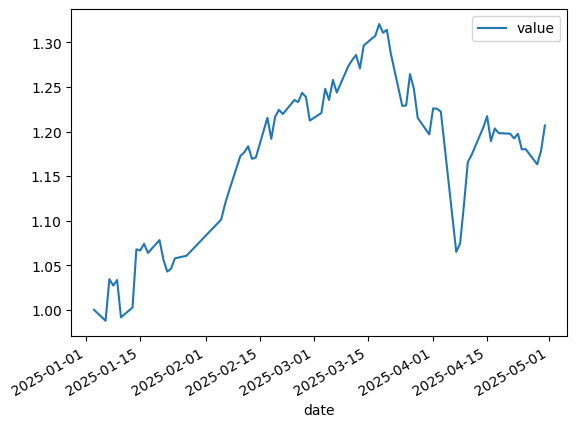

In [1]:
import pandas as pd
import pf_trader

prices = pd.read_csv("prices.csv", parse_dates=["date"])
prices = prices[["date", "instrument", "price"]]
factors = pd.read_csv("factors.csv", parse_dates=["date"])
factors = factors[["date", "instrument", "factor"]]


def main(state: pf_trader.State) -> pf_trader.StrategyResult:
    if state.date.weekday() == 0:
        return None
    df = factors[factors["date"] == state.date]
    df = df.sort_values("factor", ascending=True).head(50)
    df["weight"] = 1.0 / 50
    return df[["instrument", "weight"]]


res = pf_trader.run(
    strategy=main,
    prices=prices,
)

res.values.plot(x="date", y="value")
res.trades['cost'].sum()